# Models performance plots per class  

## Model prediction strength over time  

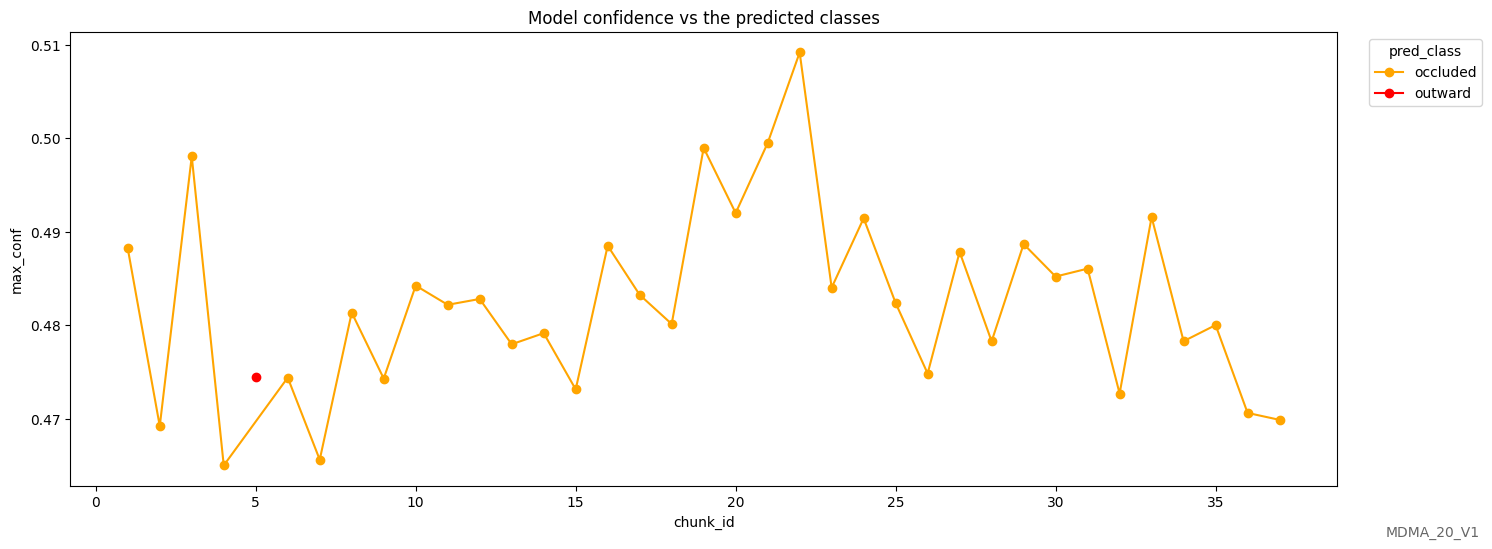

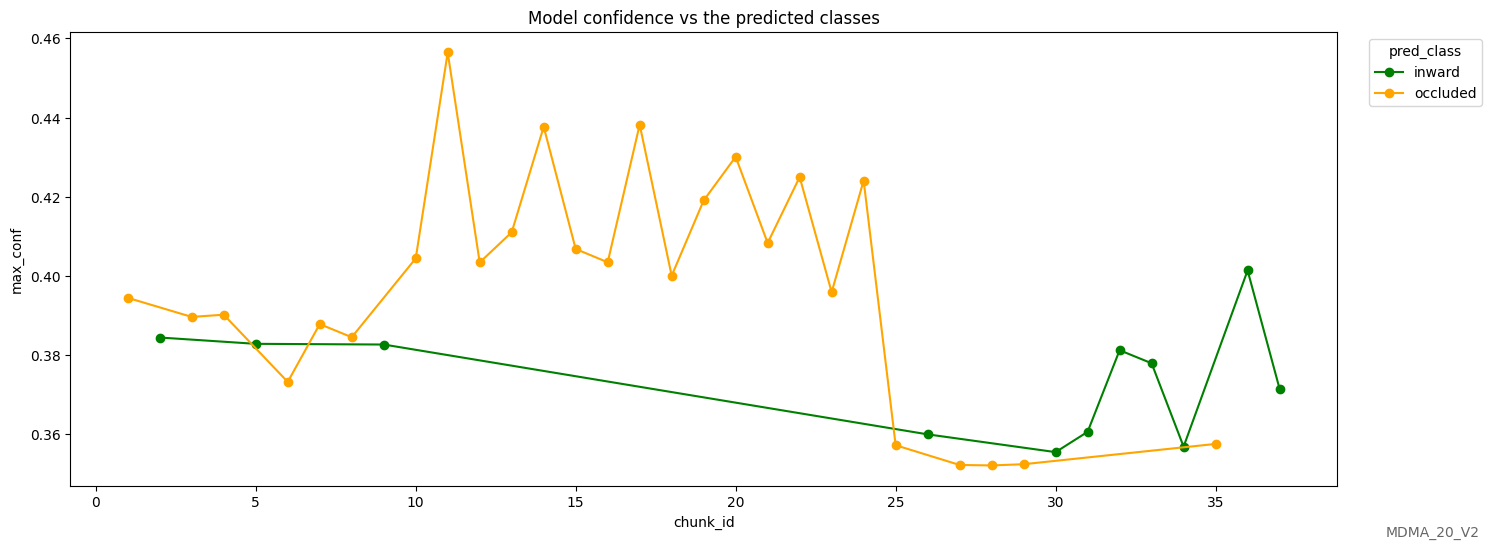

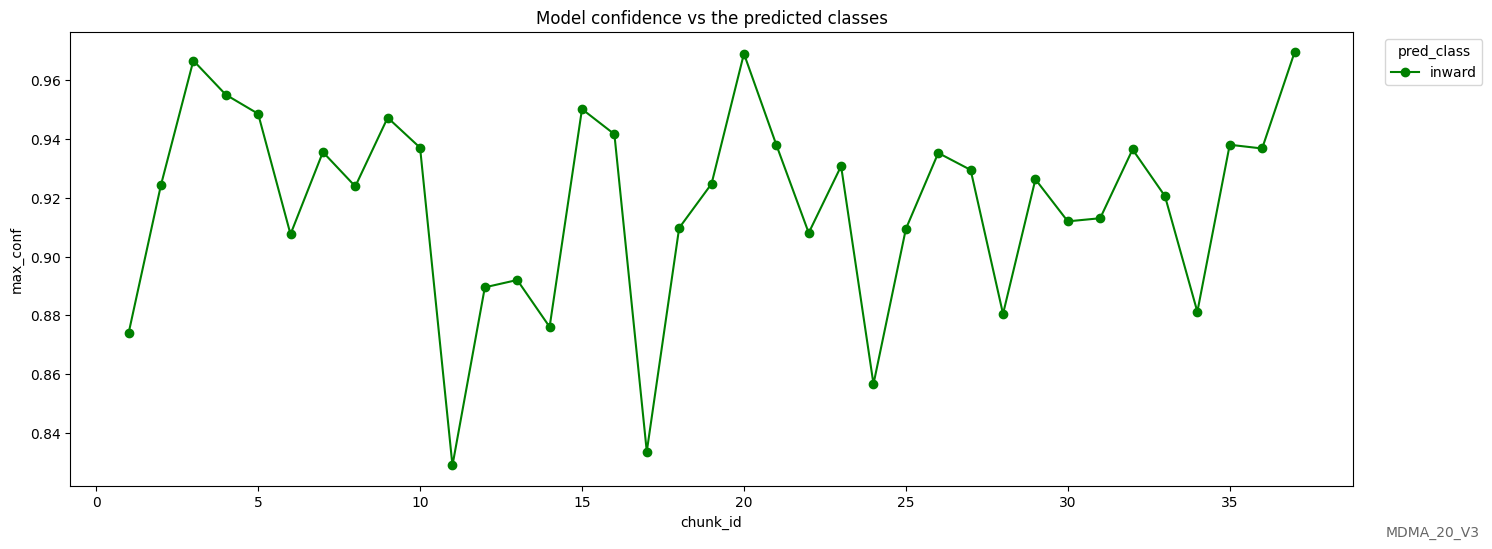

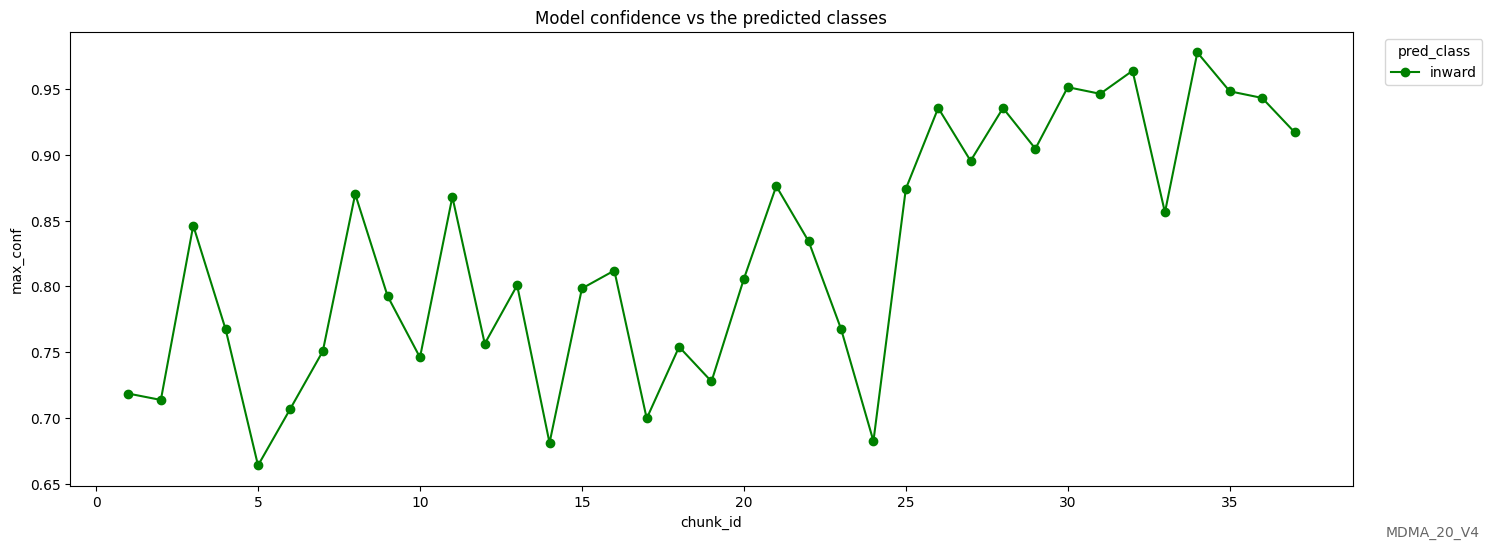

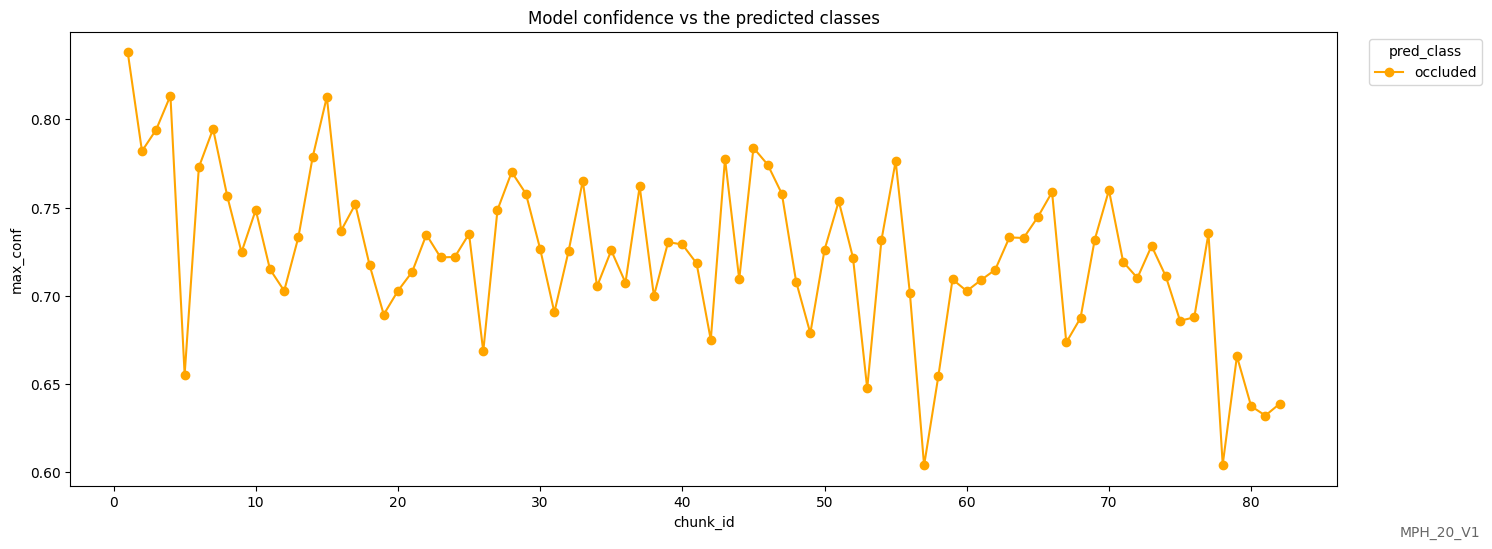

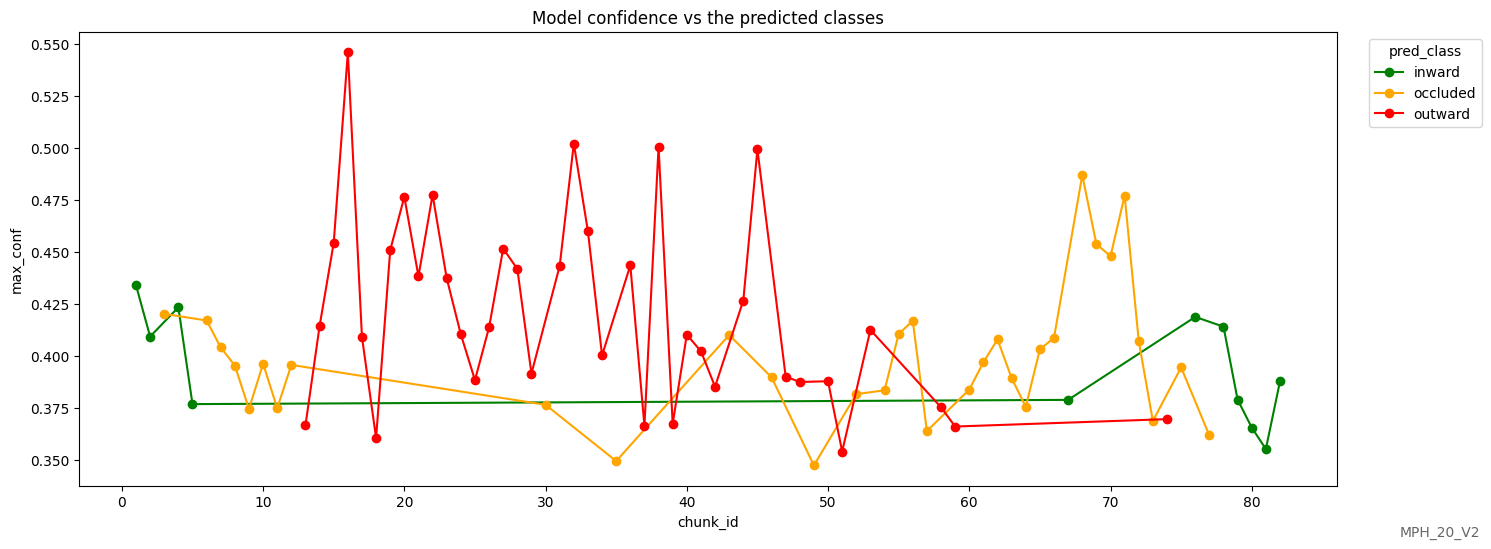

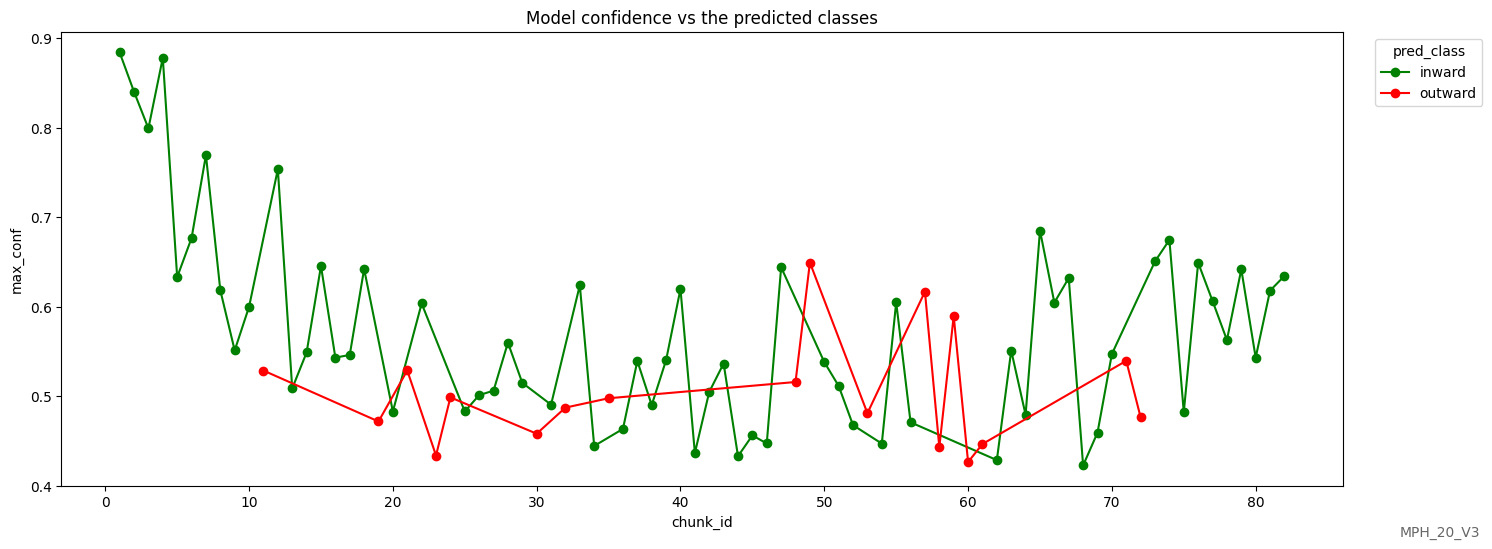

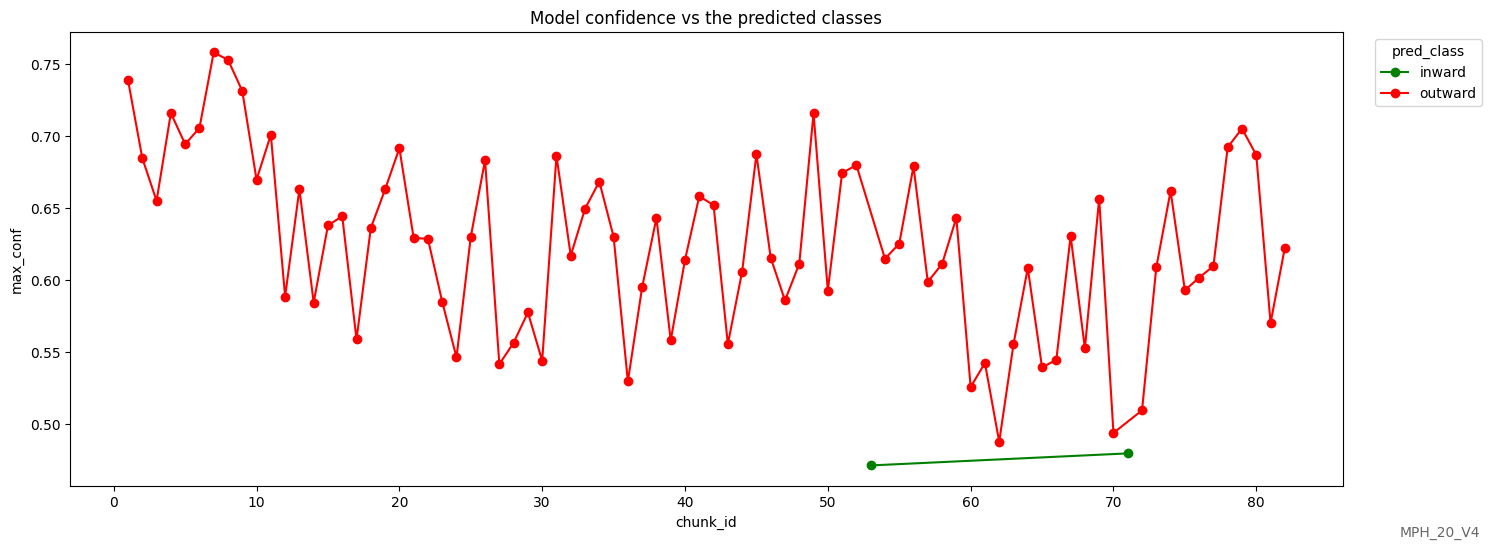

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# -------- Settings --------
base_dir = Path(r"Data\eval_CSV")
out_dir  = base_dir / "plots"
out_dir.mkdir(parents=True, exist_ok=True)

# Consistent colors for each class (case-insensitive match)
COLOR_MAP = {
    "inward":  "green",
    "occluded":"orange",
    "outward": "red",
}

# Optional: fixed legend order
CLASS_ORDER = ["inward", "occluded", "outward"]

# -------- Loop over CSVs --------
for csv_path in sorted(base_dir.glob("*.csv")):
    run_name = csv_path.stem

    df = pd.read_csv(csv_path)
    df = df.sort_values(["pred_class", "chunk_id"])

    fig, ax = plt.subplots(figsize=(15, 5.5))

    # Iterate in a stable order
    for cls in CLASS_ORDER:
        g = df[df["pred_class"].str.lower() == cls]
        if g.empty:
            continue
        ax.plot(
            g["chunk_id"],
            g["max_conf"],
            marker="o",
            linewidth=1.5,
            label=cls, 
            color=COLOR_MAP[cls]
        )

    # (If there are unexpected classes, plot them in gray)
    others = df[~df["pred_class"].str.lower().isin(CLASS_ORDER)]
    for cls, g in others.groupby(others["pred_class"].str.lower()):
        ax.plot(
            g["chunk_id"],
            g["max_conf"],
            marker="o",
            linewidth=1.5,
            label=cls,
            color="gray"
        )

    ax.set_xlabel("chunk_id")
    ax.set_ylabel("max_conf")
    ax.set_title("Model confidence vs the predicted classes")
    ax.legend(title="pred_class", bbox_to_anchor=(1.02, 1), loc="upper left")

    # stamp file name
    fig.text(0.99, 0.01, run_name, ha="right", va="bottom", fontsize=10, alpha=0.6)

    plt.tight_layout()
    plt.show()  # comment out to suppress display

    # fig.savefig(out_dir / f"{run_name}_plot.png", dpi=300, bbox_inches="tight")
    # plt.close(fig)


## Box/Violin 

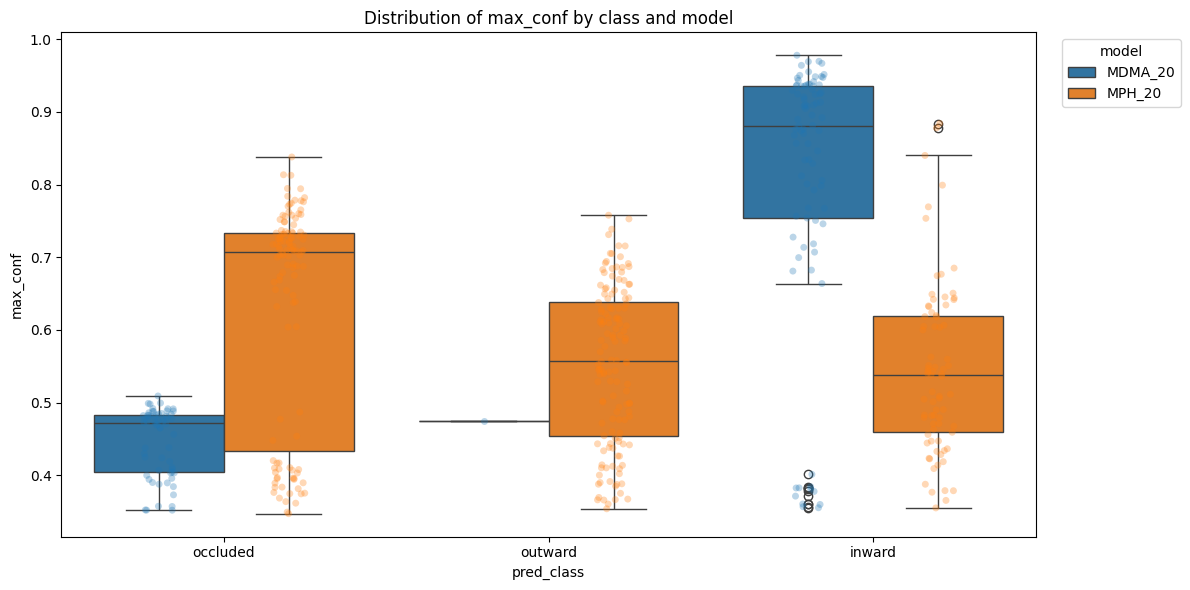

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re

# -------- Load & label all CSVs --------
base_dir = Path(r"Data\eval_CSV")
files = sorted(base_dir.glob("*.csv"))

def extract_model(stem):
    # e.g. "MPH_20_V4" -> "MPH_20" (customize this regex to your naming)
    m = re.match(r"([A-Z]+_\d+)", stem)
    return m.group(1) if m else stem

dfs = []
for f in files:
    stem = f.stem
    df = pd.read_csv(f)
    df["run_name"] = stem
    df["model"] = extract_model(stem)   # 4 models
    dfs.append(df)
df_all = pd.concat(dfs, ignore_index=True)

# -------- Plot: box + strip --------
plt.figure(figsize=(12,6))
sns.boxplot(data=df_all, x="pred_class", y="max_conf", hue="model")
sns.stripplot(data=df_all, x="pred_class", y="max_conf", hue="model",
              dodge=True, alpha=0.3, marker="o", linewidth=0, legend=False)
plt.title("Distribution of max_conf by class and model")
plt.xlabel("pred_class"); plt.ylabel("max_conf")
plt.legend(title="model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
